### **Tools & Binding**

In [1]:
import os
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate

os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
model = ChatGoogleGenerativeAI(
    model = "gemini-3.6-flash"
)


print(f"[INFO] Model : {model.model} Loaded Successfully!")

[INFO] Model : gemini-3.6-flash Loaded Successfully!


### **DuckDuckGo Search tool**

In [2]:
from langchain_community.tools import DuckDuckGoSearchRun

duck_search = DuckDuckGoSearchRun()

duck_search.invoke("Latest Scorecard update on Ind vs Sl test series")

/tmp/ipykernel_22285/1408362800.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun


'7 hours ago - India are now 5 down for 357. ... Prabath Jayasuriya to Devdutt Padikkal, Flighted up, on off; Padikkal brings out the reverse and rolls his wrists over the ball. Plays it into the ground and despite the leap by Dhananjaya de Silva at slip to ... 4 hours ago - IND vs SL Live Score, India vs Sri Lanka Test Series 2026 1st Test Day 3 Match Live Cricket Score Updates: India are yet to pick up a wicket in the afternoon session as Sonal Dinusha and Niroshan Dickwella have managed to put on a decent partnership on Day 3 of the 1st Test in Galle on Monday. 8 hours ago - 16:55 Local Time, 11:25 GMT: India will be slightly disappointed to let Sri Lanka get to 284 from 59/4 but 178 is still a healthy lead. Dickwella and Dinusha were involved a determined 146-run stand that not only frustrated the Indians but also ... 5 hours ago - Check India vs Sri Lanka 1st Test 2026 live cricket score from Galle. Get the live score updates and ball by ball commentary of IND vs SL 1st Test, 2026

### **Arxiv tool - research paper**

In [3]:
# from langchain_community.tools import ArxivQueryRun
# from langchain_community.utilities import ArxivAPIWrapper

# arxiv_query = ArxivQueryRun(api_wrapper=ArxivAPIWrapper(), max_results = 2)
# arxiv_query.invoke("Transformer models in NLP")

### **Wikipedia Search Tool**

In [4]:
import wikipedia
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

wikipedia.set_user_agent(
    "LangGraphLearning/1.0 (technoriku@gmail.com)"
)


wiki_query = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
wiki_query.invoke("Who is Shubman Gill?")

'Page: Shubman Gill\nSummary: Shubman Gill (born 8 September 1999) is an Indian international cricketer who plays for the India national team. Gill captains India in Tests and ODIs, the Gujarat Titans in the Indian Premier League and Punjab when he plays first-class cricket. He has also captained India in T20I. A right-handed batsman, Gill represents Punjab in domestic cricket.\nIn ODI cricket, he is the fastest player to reach 2000 runs, in 38 innings, and 2500 runs, in 50 innings. He also holds the record for the youngest cricketer to score a double century in ODIs at the age of 23. With his country, he won the 2025 ICC Champions Trophy as vice captain. He made his List-A debut against Vidarbha in 2017 and first-class debut for Punjab against Bengal in the 2017–18 Ranji Trophy, scoring a half-century in the game, and 129 runs in the last match against Services.\nAs vice-captain of the Indian under-19 team, Gill scored 372 runs at an average of 124.00 in the 2018 Under-19 Cricket Worl

### **Custom Tool**

In [5]:
from langchain.tools import tool

@tool
def personal_info(name: str):
    """Use this tool to get personal information about someone."""

    info = {
        "Manabendu" : "He is a bengali fat boy!!",
        "Pramith" : "He is a cunning short mallu!!",
        "Jevial" : "The bosss baby of our gang!!"
    }

    return info.get(name, f"No information is available about the person {name}")

In [6]:
@tool
def wiki_tool(topic:str):
    """Use this tool for wikipedia search"""
    return wiki_query.invoke(topic)

In [7]:
@tool
def duckduckgo_tool(topic:str):
    """Use this tool for browser search and to get the latest updated about the given topic."""
    return duck_search.invoke(topic)

### **Tool Binding**

In [8]:
tools = [duckduckgo_tool, wiki_tool, personal_info]

model_with_tools = model.bind_tools(tools)

In [9]:
response = model_with_tools.invoke(
    "What is the latest scorecard update on ind vs sl test series"
)


In [10]:
response.tool_calls

[{'name': 'duckduckgo_tool',
  'args': {'topic': 'ind vs sl test series latest scorecard update'},
  'id': 'call_4471392',
  'type': 'tool_call'}]

### **LangGraph Creation**

In [11]:
from typing import TypedDict, List

class graph_schema(TypedDict):
    messages: List

#### **Creating a LLM node**

In [12]:
def llm_node(state: graph_schema) -> graph_schema:
    messages = state['messages']

    response = model_with_tools.invoke(messages)

    state['messages'] = messages + [response]
    return state

### **Tool Node**

In [13]:
# from langgraph.prebuilt import ToolNode
from langchain_core.messages import ToolMessage, AIMessage

def tool_node(state: graph_schema) -> graph_schema:

    messages = state['messages']
    tool_results = []
    tools_by_name = {tool.name: tool for tool in tools}

    for tool_call in messages[-1].tool_calls:

        tool = tools_by_name[tool_call['name']]

        obs = tool.invoke(tool_call['args'])

        tool_results.append(ToolMessage(content=str(obs), tool_call_id = tool_call['id']))

    state['messages'] = messages + tool_results
    return state

### **Create a StateGraph**

In [14]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

### **Creating a Conditional Edge Function**

In [15]:
def if_tool_call(state: graph_schema):
    last_message = state['messages'][-1]

    if isinstance(last_message, AIMessage) and last_message.tool_calls:
        return "tool_node"
    
    return "end"

In [16]:
graph.add_node("llm_node", llm_node)
graph.add_node("tool_node", tool_node)

graph.add_edge(START, "llm_node")
graph.add_conditional_edges("llm_node", if_tool_call, {"tool_node":"tool_node", "end" : END})
graph.add_edge("tool_node", "llm_node")

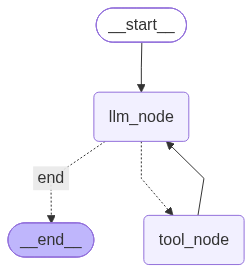

In [17]:
react_graph = graph.compile()
react_graph

### **Graph Invocation**

In [18]:
from langchain_core.messages import HumanMessage

react_graph.invoke({
    "messages":[HumanMessage(content="Latest ScoreCard updated between IND vs SL.")]
})

{'messages': [HumanMessage(content='Latest ScoreCard updated between IND vs SL.', additional_kwargs={}, response_metadata={}),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'duckduckgo_tool', 'arguments': '{"topic": "IND vs SL latest cricket match scorecard live updates"}'}, '__gemini_function_call_thought_signatures__': {'call_4713502': 'EokGCoYGARFNMg/6raKmcAzkUqgVPHWT/2Y0wUkQi7X5NubyzaBOpB3pQtbv3M4qo8eLRMloJSYNnXyuCGRwP2oYFt38rmIZDMfA5Y1Zv4yUogO5wLG30Zmbr7GF8q0hjphZsNq4L6HDNGXH12lTE/JZ+vbMTEwmDbIwS1zF0Tcubb6/BsZVtctw24AXEm0XmqFY7sC7C81Q0aNZYaVGHLsKck2t77KEUBFapuuZuveLXhVSB0D0fMuKMuKcLI9aA26a9LK2grDj4YHnDbCwJzehSAaqRFk5yQzcXc28GB5swyuL9CPsLK1SWZslhAxIoSi0hVeyyz7nLLapePm6wcoYiOygWMNrBvnKw1gZAfAc1O6W2TTY7qR2TsQaoa6GCN3XKjJrO8O2wkrs9B2oS7po40dk/Oqqm4Puarf4ocXh22+uW9NmDzwgNFKLmhB8cZn4+hVyabsa2BGtKQEVZfnLhiC6gr0AnF9GZjCZi3EQCFHPBXfhDF6fEHrCZ9LF/Kb7CdmWcZclCpQTqz4B2TCW1EnMXlikBO4HvLQ8QObTngvFGXf4vhbvyjGwIZ7fOlFkpxZnKt/XIEY6e6KMes4IwlEBGKvn62RDvx68jd18ZR0X4NvEdzEpnG48